In [1]:
import math
import copy
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from sklearn.utils import shuffle
# from keras.layers import Conv2D, MaxPooling2D
# from keras.layers import Dense, Flatten
# from keras.models import Sequential

# Loading the dataset and perform splitting
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = shuffle(x_train, y_train, random_state=42)
x_test, y_test = shuffle(x_test, y_test, random_state=42)

# Peforming reshaping operation
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normalization
x_train = x_train / 255
x_test = x_test / 255

# One Hot Encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


In [2]:
# # Building the Model Architecture
# model = Sequential()
# model.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1), padding='same'))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Flatten())
# model.add(Dense(120, activation='relu'))
# model.add(Dense(84, activation='relu'))
# model.add(Dense(10, activation='softmax'))

# model.summary()
# model.compile(loss=keras.metrics.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])
# model.fit(x_train, y_train, batch_size=32, epochs=5, verbose=1, validation_data=(x_test, y_test))
# model.save("Lenet.h5")
# model.save("Lenet.keras")

In [3]:
model = keras.models.load_model('Lenet.h5')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,708 (241.05 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [4]:
N  = 255
N_b  = 4294967296
Z = -127
def get_scale_param(tensor):
    """Return scale param of input tensor"""
    a = tf.math.reduce_min(tensor).numpy()
    b = tf.math.reduce_max(tensor).numpy()
    S = (b - a) / (N - 1)

    return S

def quantize_weight(tensor, output_scale):
    """Quantize input tensor follow algorithm: q = (r - a) / S + Z"""
    a_w = tf.math.reduce_min(tensor[0])
    b_w = tf.math.reduce_max(tensor[0])
    r_w = tf.math.minimum(tf.math.maximum(tensor[0], a_w), b_w)
    S_w = (b_w - a_w) / (N - 1)
    tensor[0] = tf.math.floor((r_w - a_w) / S_w) + Z

    # a_b = tf.math.reduce_min(tensor[1])
    # b_b = tf.math.reduce_max(tensor[1])
    # r_b = tf.math.minimum(tf.math.maximum(tensor[1], a_b), b_b)
    # S_b = (b_b - a_b) / output_scale
    # tensor[1] = tf.math.floor((r_b - a_b) / S_b) + Z
    # tensor[1] = tf.math.floor(tensor[1]/output_scale)

def quantize_output(output_tensor, S1, S2, S3):
    M = S1 * S2 / S3
    n = math.floor(math.log2(1 / M))
    M0 = M * math.pow(2, n)
    q_M = M0 * (math.pow(2,31) - 1)
    output_tensor = output_tensor * q_M / ((math.pow(2,31) - 1) * math.pow(2, n))

    return output_tensor

def quantize_output_without_weight(tensor):
    """Quantize input tensor follow algorithm: q = (r - a) / S + Z"""
    a = tf.math.reduce_min(tensor)
    b = tf.math.reduce_max(tensor)
    r = tf.math.minimum(tf.math.maximum(tensor, a), b)
    S = (b - a) / (N - 1)
    tensor = tf.math.floor((r - a) / S) + Z

    return tensor


    
    

In [ ]:
TEST_AMOUNT = 10
# Re-scale input to 0-255
layer_output = x_test[:TEST_AMOUNT] * 255
layers = model.layers
refer_layers = copy.deepcopy(model.layers)
range_layer_scale = {}
range_layer_input_scale = {}
range_layer_output_scale = {}

# Get range for each layer
for i in range(len(layers)):
    # Input
    range_layer_input_scale[layers[i].name] = get_scale_param(layer_output)
    # Output
    layer_output = layers[i](layer_output)
    print(f"{tf.math.reduce_min(layer_output)}, {tf.math.reduce_max(layer_output)}")
    range_layer_output_scale[layers[i].name] = get_scale_param(layer_output)
    if len(layers[i].get_weights()) > 0:
        # Weight
        range_layer_scale[layers[i].name] = get_scale_param(layers[i].get_weights()[0])
        # Quantize weight of each layer
        q_layer_weight = layers[i].get_weights()
        quantize_weight(q_layer_weight, range_layer_output_scale[layers[i].name])
        layers[i].set_weights(q_layer_weight)

# Re-scale input to 0-255
layer_output = x_test[:TEST_AMOUNT] * 255
refer_layer_output =  x_test[:TEST_AMOUNT] 
# for i in range(len(layers) - 1):
for i in range(2):
    # Get output of each layer (inference)
    layer_output = layers[i](layer_output)
    refer_layer_output = refer_layers[i](refer_layer_output)
    print(layers[i].name)

    # Quantize output of each layer
    if len(layers[i].get_weights()) > 0:
        layer_output = quantize_output(layer_output, range_layer_input_scale[layers[i].name], range_layer_scale[layers[i].name], range_layer_output_scale[layers[i].name])
    else:
        pass
    layer_output = quantize_output_without_weight(layer_output)

# print(layers[-1].name)
# layer_output = layers[-1](layer_output)
# refer_layer_output = refer_layers[-1](refer_layer_output)


0.0, 541.1768188476562
0.0, 541.1768188476562
0.0, 927.6016845703125
0.0, 927.6016845703125
0.0, 927.6016845703125
0.0, 2280.033203125
0.0, 2757.257080078125
0.0, 1.0
conv2d
max_pooling2d


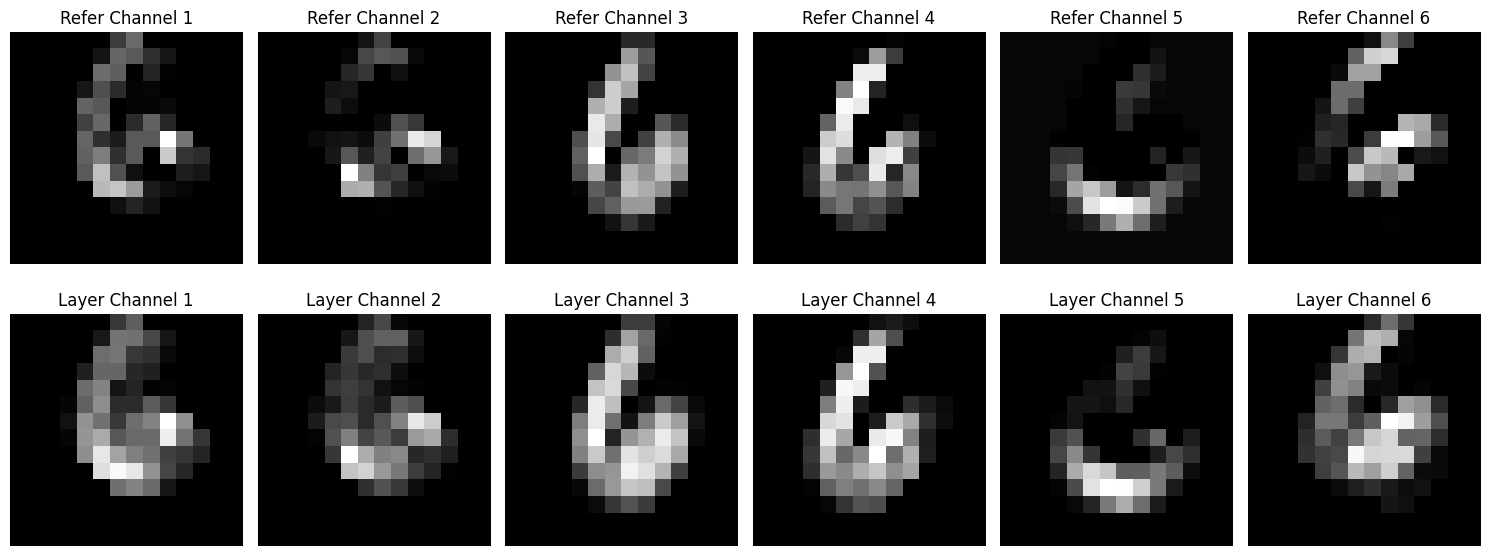

In [6]:

refer_layer_output = quantize_output_without_weight(refer_layer_output)
import numpy as np
import matplotlib.pyplot as plt

# Create a figure with 2 rows and 6 columns
fig, axes = plt.subplots(2, 6, figsize=(15, 6))

# Plot 6 channels for refer_layer_output (first row)
for i in range(6):
    img = refer_layer_output[0].numpy()[:, :, i]
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Refer Channel {i+1}')
    axes[0, i].axis('off')

# Plot 6 channels for layer_output (second row)
for i in range(6):
    img = layer_output[0].numpy()[:, :, i]
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'Layer Channel {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
print(tf.math.reduce_max(layer_output))
print(tf.math.reduce_min(layer_output))
print()
print(tf.math.reduce_max(refer_layer_output))
print(tf.math.reduce_min(refer_layer_output))

tf.Tensor(127.0, shape=(), dtype=float32)
tf.Tensor(-127.0, shape=(), dtype=float32)

tf.Tensor(127.0, shape=(), dtype=float32)
tf.Tensor(-127.0, shape=(), dtype=float32)


In [8]:
print(tf.math.reduce_max(layer_output - refer_layer_output))
print(tf.math.reduce_min(layer_output - refer_layer_output))
print()
print(tf.math.reduce_mean(layer_output - refer_layer_output))
print(tf.math.reduce_sum(layer_output - refer_layer_output))

tf.Tensor(80.0, shape=(), dtype=float32)
tf.Tensor(-18.0, shape=(), dtype=float32)

tf.Tensor(6.931463, shape=(), dtype=float32)
tf.Tensor(81514.0, shape=(), dtype=float32)


In [9]:
print(tf.math.round(layer_output))
print((layer_output))
print()
print(tf.math.round(refer_layer_output))
print()
print(y_test[:TEST_AMOUNT])

tf.Tensor(
[[[[-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   ...
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]]

  [[-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   ...
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]]

  [[-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   ...
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]]

  ...

  [[-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   ...
   [-127. -127. -127. -127. -127. -127.]
   [-127. -127. -127. -127. -127. -127.]
   [-